# Text Processing

Obviously, since we can't process categorical/discrete data like text, images, audio directly with DL models, we gotta embed them.

While we can use pretrained models such as Word2Vec to generate embeddings for machine learning models, **LLMs commonly produce their own embeddings that are part of the input layer and are updated during training**. The advantage of optimizing the embeddings as part of the LLM training instead of using Word2Vec is that the embeddings are optimized to the specific task and data at hand.

The embedding size/dimension depends on the model, but for GPT3, $D = 12,288$

## Tokenizing

In [2]:
import re
import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
       "the-verdict.txt")
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x7ac0d915a2a0>)

In [3]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 



Our goal is to tokenize this 20,479-character short story into individual words and spe- cial characters that we can then turn into embeddings for LLM training.

In [4]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:10])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius']


## Tokens into Token IDs

In [5]:
all_words = sorted(set(preprocessed))
all_words.extend(['<|endoftext|>', '<|unk|>'])

vocab_size = len(all_words)
vocab = {token:integer for integer,token in enumerate(all_words)}

let's write a tokenizer!

In [6]:
list(vocab.items())[-5:]

[('younger', 1127),
 ('your', 1128),
 ('yourself', 1129),
 ('<|endoftext|>', 1130),
 ('<|unk|>', 1131)]

In [7]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {s: i for i, s in vocab.items()}
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[token] for token in preprocessed]
        return ids
    def decode(self, ids):
        text = " ".join([self.int_to_str[id] for id in ids])

        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

tokenizer = SimpleTokenizerV1(vocab)
print(tokenizer.encode('But Carlo like to think things!'))
print(tokenizer.decode([22, 24, 628, 1016, 998, 997, 0]))

[22, 24, 628, 1016, 998, 997, 0]
But Carlo like to think things!


Great - one problem though: notice how if we try:

In [8]:
tokenizer.encode('Hello')

KeyError: 'Hello'

We get an error, because 'Hello' doesn't exist in our vocabulary.

## Adding Special Context Tokens

We want to introduce two new special context tokens: '<|unk|>' and '<|endoftext|>', that designate unknown tokens and endoftext tokens respectively.

In [9]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {s: i for i, s in vocab.items()}
    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]

        ids = [self.str_to_int[token] for token in preprocessed]
        return ids
    def decode(self, ids):
        text = " ".join([self.int_to_str[id] for id in ids])

        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode('But Carlo like to think things fah fah fah  !'))
print(tokenizer.decode([22, 24, 628, 1016, 998, 997, 0, 1131]))

[22, 24, 628, 1016, 998, 997, 1131, 1131, 1131, 0]
But Carlo like to think things! <|unk|>


In [10]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.
[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]
<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


Depending on the LLM, there are also other special tokens:
- [BOS] (beginning of sequence)
- [EOS] (end of sequence)
- [PAD] (padding )

## Byte Pair Encoding
tiktoken is an open source library that implements BPE very efficienctly (based on rust!)

In [11]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [12]:
# let's use this like our tokenizer
text = (
            "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
             "of someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [13]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


BPE tokenizers can handle unknown words without using the <|unk|> token by breaking down words that aren't in its predefined vocabulary into smaller subword units or even individual characters! 

Basically how BPE works:
1. Starting w/ vocab containing only characters and an end of word symbol.
2. Using a corpus of text, find the most common adjacent characters "a;b"; add "ab" as a subword.
3. Replace instances of the character pair with the new subword; repeat until desired vocab size.

**Example**
1. Count for most freq. pair (e + a -> frequent) (a + r -> frequent)
2. Suppose "ar" most frequent, then add "ar" to vocab, w/ replacement
3. Repeat until desired vocab size (e.g. 30k tokens)

In [14]:
unk_text = "Akwirw ier"

unk_ints = tokenizer.encode("Akiwrw ier")
print(unk_ints)
decoded_ints = tokenizer.decode(unk_ints)
print(decoded_ints)

[32, 4106, 18351, 86, 220, 959]
Akiwrw ier


## Data Sampling with a Sliding Window

In [15]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

enc_sample = enc_text[:50]

5145


In [16]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1:context_size + 1]
print(x)
print(y)

[40, 367, 2885, 1464]
[367, 2885, 1464, 1807]


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [1]:
def create_dataloader_v1(txt, batch_size = 4, max_length = 256, stride = 128, shuffle = True, drop_last = True, num_workers = 0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size = batch_size,
        shuffle = shuffle,
        drop_last = drop_last,
        num_workers = num_workers

    )
    return dataloader

In [19]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)

inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## Creating Token Embeddings

The **last step** is to convert the token IDs into embedding vectors.

The first step is to initialize these embedding weights with random values.

In [26]:
import torch

input_ids = torch.tensor([2, 3, 5, 1])

# suppose we have a small vocabulary of 6 words and we want to create embeddings in size 3 (GPT3 D = 12,288, btw)
torch.manual_seed(123)

vocab_size = 6
output_dim = 3

embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


notice that this is fourth row of the embedding matrix! we can conclude:

the embedding layer is essentially a **lookup operation** that retrieves rows from the embedding layer's weight matrix via a token ID.

In [27]:
embedding_layer(input_ids)

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

## Encoding Word Positions
One problem we still need to deal with is that LLM self-attention doesn't have a notion of position or order for the tokens within a sequence - i.e. currently, the same token ID always gets mapped to the same vector representation of where the token ID is positioned in the input sequence.

**Absolute Position Embeddings** are directly associated with specific positions in a sequence.


**Relative Position Embeddings** are based on the relative position of distance between tokens.

In [28]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size = 8, max_length = max_length, stride = max_length, shuffle = False
)

data_iter = iter(dataloader)

inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [29]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [ ]:
# now, for the absoute embedding:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [32]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


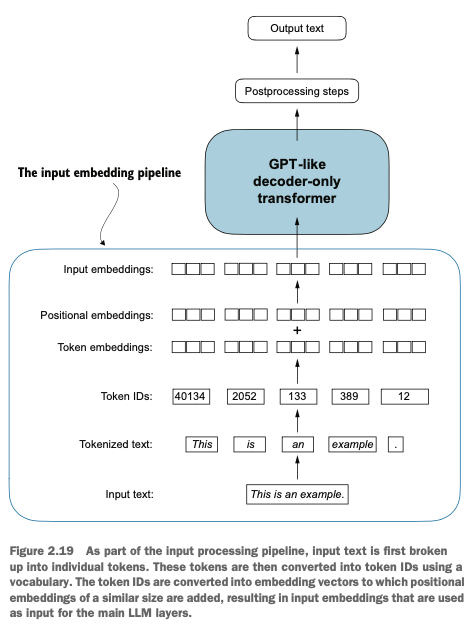

In [2]:
# recap code

corpus = "Welcome to the show! This is the circus of the sun, otherwise known as the greatest show on earth. It is of course hosted by the greatest showman in the world, myself, and I would like to welcome and thank you for your time."

import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding('gpt2')

class GPT2Dataset(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.inputs = []
        self.targets = []

        token_ids = tokenizer.encode(txt)

        for i in range(0, len(token_ids) - max_length, stride):
            self.inputs.append(torch.tensor(token_ids[i:i + max_length]))
            self.targets.append(torch.tensor(token_ids[i + 1 : i + max_length + 1]))
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = GPT2Dataset(txt = corpus, tokenizer = tokenizer, max_length = 4, stride = 4)
dataloader = DataLoader(
    dataset,
    batch_size = 8,
    shuffle = True,
    drop_last = True,
    num_workers = 0

)

vocab_size = tokenizer.n_vocab
embedding_dim = 256

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)
pos_embedding_layer = torch.nn.Embedding(4, embedding_dim)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

token_embeddings = embedding_layer(inputs)
pos_embeddings = pos_embedding_layer(torch.arange(4))

input_embeddings = token_embeddings + pos_embeddings
input_embeddings.shape
 

ConnectionError: HTTPSConnectionPool(host='openaipublic.blob.core.windows.net', port=443): Max retries exceeded with url: /gpt-2/encodings/main/vocab.bpe (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x10eb66d50>: Failed to establish a new connection: [Errno 8] nodename nor servname provided, or not known'))